
Import Library/ Package
---



In [ ]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 32.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 42.0 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import streamlit as st
import requests
from google.colab import files
from babel.numbers import format_currency
sns.set(style='dark')
import datetime as dt
plt.style.use('default')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Data Wrangling

Gathering Data

In [ ]:
df_main = pd.read_csv('/content/drive/MyDrive/Dataset Capstone/nilai-gizi.csv')
df_main

,name,manufacturer,serving_size,energy_kcal,protein_g,carbohydrate_g,fat_g,sugar_g,sodium_mg,fiber_g,...,carbohydrate_percentage_dv,fat_percentage_dv,sodium_percentage_dv,Lemak jenuh,Natrium,Protein,Karbohidrat total,Energi,Lemak total,Serat pangan
0,"Ikan sunu, asin, mentah",Tidak Diketahui,20.30 g,199.0,34.1,7.1,3.8,0.0,377.0,0.0,...,2.18,5.67,25.13,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,"Soto pekalongan, masakan",Tidak Diketahui,1.30 g,94.0,3.0,5.1,6.8,0.0,0.0,0.3,...,1.57,10.15,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Marie duo,Tidak Diketahui,1 g,15.0,1.0,14.0,3.5,5.0,85.0,1.0,...,4.31,5.22,5.67,10.0,6.0,0.0,0.0,0.0,0.0,0.0
3,"Kaparende, sayur",Tidak Diketahui,1.30 g,38.0,2.4,2.6,2.0,0.0,170.0,1.5,...,0.80,2.99,11.33,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Kacang lebui / iris,Tidak Diketahui,3.60 g,346.0,16.5,66.6,1.5,0.0,17.0,37.3,...,20.49,2.24,1.13,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1646,V-soy Soya bean Milk Low Sugar,PT. Sukanda djaya,2.70 g,56.0,2.7,5.2,2.7,2.2,0.0,0.0,...,1.60,4.03,0.00,6.0,0.0,5.0,0.0,0.0,5.0,0.0
1647,Prenagen Esensis,PT.Sanghiang perkasa,6 g,150.0,6.0,29.0,1.0,0.0,150.0,0.0,...,8.92,1.49,10.00,0.0,10.0,10.0,9.0,0.0,0.0,0.0
1648,"Pisang ketip, segar",Tidak Diketahui,0.70 g,145.0,1.1,34.5,0.3,0.0,4.0,6.6,...,10.62,0.45,0.27,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1649,"Buaya, daging, dendeng, mentah",Tidak Diketahui,2.50 g,365.0,49.6,30.8,4.8,0.0,500.0,0.0,...,9.48,7.16,33.33,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
df_bmi= pd.read_csv('/content/drive/MyDrive/Dataset Capstone/500_Person_Gender_Height_Weight_Index.csv')
df_bmi

,Gender,Height,Weight,Index
0,Male,174,96,4
1,Male,189,87,2
2,Female,185,110,4
3,Female,195,104,3
4,Male,149,61,3
...,...,...,...,...
495,Female,150,153,5
496,Female,184,121,4
497,Female,141,136,5
498,Male,150,95,5


In [ ]:
df_nutri = pd.read_csv('/content/drive/MyDrive/Dataset Capstone/nutrition.csv')
df_nutri

,id,calories,proteins,fat,carbohydrate,name,image
0,1,280.0,9.2,28.4,0.0,Abon,https://img-cdn.medkomtek.com/PbrY9X3ignQ8sVuj...
1,2,513.0,23.7,37.0,21.3,Abon haruwan,https://img-global.cpcdn.com/recipes/cbf330fbd...
2,3,0.0,0.0,0.2,0.0,Agar-agar,https://res.cloudinary.com/dk0z4ums3/image/upl...
3,4,45.0,1.1,0.4,10.8,Akar tonjong segar,https://images.tokopedia.net/img/cache/200-squ...
4,5,37.0,4.4,0.5,3.8,Aletoge segar,https://nilaigizi.com/assets/images/produk/pro...
...,...,...,...,...,...,...,...
1341,1342,42.0,1.2,0.6,9.3,Wortel Segar,https://www.astronauts.id/blog/wp-content/uplo...
1342,1343,37.0,1.0,0.6,8.3,Wortel kukus,https://www.wikihow.com/images_en/thumb/b/bf/S...
1343,1344,28.0,0.7,0.5,6.3,Wortel rebus,https://asset-a.grid.id/crop/0x222:594x690/700...
1344,1345,254.0,3.0,1.1,58.1,Yangko,https://serikatnews.com/wp-content/uploads/202...


Asessing Data

df_main

In [ ]:
df_main.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1651 entries, 0 to 1650
Data columns (total 22 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   name                        1651 non-null   object 
 1   manufacturer                1651 non-null   object 
 2   serving_size                1651 non-null   object 
 3   energy_kcal                 1651 non-null   float64
 4   protein_g                   1651 non-null   float64
 5   carbohydrate_g              1651 non-null   float64
 6   fat_g                       1651 non-null   float64
 7   sugar_g                     1651 non-null   float64
 8   sodium_mg                   1651 non-null   float64
 9   fiber_g                     1651 non-null   float64
 10  energy_percentage_dv        1651 non-null   float64
 11  protein_percentage_dv       1651 non-null   float64
 12  carbohydrate_percentage_dv  1651 non-null   float64
 13  fat_percentage_dv           1651 

In [ ]:
df_main.isna().sum()

,0
name,0
manufacturer,0
serving_size,0
energy_kcal,0
protein_g,0
carbohydrate_g,0
fat_g,0
sugar_g,0
sodium_mg,0
fiber_g,0


In [ ]:
df_main.duplicated().sum()

np.int64(0)

In [ ]:
df_main.describe()

,energy_kcal,protein_g,carbohydrate_g,fat_g,sugar_g,sodium_mg,fiber_g,energy_percentage_dv,protein_percentage_dv,carbohydrate_percentage_dv,fat_percentage_dv,sodium_percentage_dv,Lemak jenuh,Natrium,Protein,Karbohidrat total,Energi,Lemak total,Serat pangan
count,1651.000000,1651.000000,1651.000000,1651.000000,1651.000000,1651.000000,1651.000000,1651.000000,1651.000000,1651.000000,1651.000000,1651.000000,1651.000000,1651.000000,1651.000000,1651.000000,1651.000000,1651.000000,1651.000000
mean,196.073349,7.531127,25.756451,7.823658,4.120230,126.557965,1.757129,9.425936,12.551962,7.925142,11.677553,8.437268,1.333737,3.881890,4.020594,2.473047,3.688068,5.193216,1.004846
std,187.077222,9.827088,25.241165,12.872256,11.490296,418.752559,3.671600,8.609724,16.378498,7.766489,19.212102,27.916910,7.914356,14.081063,12.267061,5.983389,7.955420,14.171148,6.349992
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,70.000000,1.100000,7.350000,0.500000,0.000000,0.000000,0.000000,3.720000,1.830000,2.265000,0.750000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,137.000000,3.800000,18.000000,3.300000,0.000000,6.000000,0.200000,6.510000,6.330000,5.540000,4.930000,0.400000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,295.000000,10.000000,36.000000,9.700000,2.800000,80.000000,2.000000,13.950000,16.670000,11.080000,14.480000,5.330000,0.000000,0.000000,0.000000,1.000000,5.000000,3.000000,0.000000
max,1710.000000,79.000000,205.000000,122.000000,134.000000,11998.000000,45.000000,79.530000,131.670000,63.080000,182.090000,799.870000,225.000000,136.000000,132.000000,64.000000,80.000000,183.000000,147.000000


df_bmi

In [ ]:
df_bmi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Gender  500 non-null    object
 1   Height  500 non-null    int64 
 2   Weight  500 non-null    int64 
 3   Index   500 non-null    int64 
dtypes: int64(3), object(1)
memory usage: 15.8+ KB


In [ ]:
df_bmi.isna().sum()

,0
Gender,0
Height,0
Weight,0
Index,0


In [ ]:
df_bmi.describe()

,Height,Weight,Index
count,500.000000,500.000000,500.000000
mean,169.944000,106.000000,3.748000
std,16.375261,32.382607,1.355053
min,140.000000,50.000000,0.000000
25%,156.000000,80.000000,3.000000
50%,170.500000,106.000000,4.000000
75%,184.000000,136.000000,5.000000
max,199.000000,160.000000,5.000000


In [ ]:
df_bmi[df_bmi['Index']==0]

,Gender,Height,Weight,Index
60,Female,191,54,0
62,Male,193,54,0
79,Male,181,51,0
85,Male,198,50,0
99,Female,190,50,0
150,Female,196,50,0
214,Female,185,52,0
224,Male,188,54,0
244,Female,183,50,0
273,Female,163,57,0


df_nutri

In [ ]:
df_nutri.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1346 entries, 0 to 1345
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            1346 non-null   int64  
 1   calories      1346 non-null   float64
 2   proteins      1346 non-null   float64
 3   fat           1346 non-null   float64
 4   carbohydrate  1346 non-null   float64
 5   name          1346 non-null   object 
 6   image         1346 non-null   object 
dtypes: float64(4), int64(1), object(2)
memory usage: 73.7+ KB


In [ ]:
df_nutri.isna().sum()

,0
id,0
calories,0
proteins,0
fat,0
carbohydrate,0
name,0
image,0


In [ ]:
df_nutri.duplicated().sum()

np.int64(0)

Cleaning Data

Cleaning Data BMI

In [ ]:
# Standarisasi nama kolom
df_bmi.columns = df_bmi.columns.str.strip().str.lower()

In [ ]:
df_bmi = df_bmi.drop_duplicates()

In [ ]:
df_bmi.isnull().sum()

,0
gender,0
height,0
weight,0
index,0


In [ ]:
# Standarisasi gender
df_bmi['gender'] = df_bmi['gender'].str.lower().str.strip()

/tmp/ipykernel_4949/164870234.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_bmi['gender'] = df_bmi['gender'].str.lower().str.strip()


In [ ]:
df_bmi = df_bmi[df_bmi['index'] != 0]

In [ ]:
df_bmi.describe()

,height,weight,index
count,476.000000,476.000000,476.000000
mean,169.434874,107.869748,3.859244
std,16.259927,31.571937,1.218774
min,140.000000,50.000000,1.000000
25%,155.750000,81.000000,3.000000
50%,169.000000,108.000000,4.000000
75%,183.000000,137.000000,5.000000
max,199.000000,160.000000,5.000000


Cleaning Data Main

In [ ]:
# Membuat kolom baru berisi nama makanan yang sudah dibersihkan
df_main['name_clean'] = df_main['name'].str.lower().str.strip()


In [ ]:
# Menampilkan semua nama kolom yang ada di df main
print(df_main.columns)

Index(['name', 'manufacturer', 'serving_size', 'energy_kcal', 'protein_g',
       'carbohydrate_g', 'fat_g', 'sugar_g', 'sodium_mg', 'fiber_g',
       'energy_percentage_dv', 'protein_percentage_dv',
       'carbohydrate_percentage_dv', 'fat_percentage_dv',
       'sodium_percentage_dv', 'Lemak jenuh', 'Natrium', 'Protein',
       'Karbohidrat total', 'Energi', 'Lemak total', 'Serat pangan',
       'name_clean'],
      dtype='object')


In [ ]:
df_main = df_main.drop(columns=['manufacturer'], errors='ignore')

In [ ]:
# Menghitung jumlah rows di dataset main
print("df_main:", len(df_main))


df_main: 1651


In [ ]:
# Rename kolom di df main
df_main = df_main.rename(columns={
    'energy_kcal': 'calories',
    'protein_g': 'proteins',
    'fat_g': 'fat',
    'carbohydrate_g': 'carbohydrate',
})

In [ ]:
cols = ['calories','protein','fat','carbohydrate','sugar_g','sodium_mg','fiber_g']

for col in cols:
    if col in df_main.columns:
        df_main[col] = pd.to_numeric(df_main[col], errors='coerce')

In [ ]:
df_main.head()

,name,serving_size,calories,proteins,carbohydrate,fat,sugar_g,sodium_mg,fiber_g,energy_percentage_dv,...,fat_percentage_dv,sodium_percentage_dv,Lemak jenuh,Natrium,Protein,Karbohidrat total,Energi,Lemak total,Serat pangan,name_clean
0,"Ikan sunu, asin, mentah",20.30 g,199.0,34.1,7.1,3.8,0.0,377.0,0.0,9.26,...,5.67,25.13,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"ikan sunu, asin, mentah"
1,"Soto pekalongan, masakan",1.30 g,94.0,3.0,5.1,6.8,0.0,0.0,0.3,4.37,...,10.15,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"soto pekalongan, masakan"
2,Marie duo,1 g,15.0,1.0,14.0,3.5,5.0,85.0,1.0,4.19,...,5.22,5.67,10.0,6.0,0.0,0.0,0.0,0.0,0.0,marie duo
3,"Kaparende, sayur",1.30 g,38.0,2.4,2.6,2.0,0.0,170.0,1.5,1.77,...,2.99,11.33,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"kaparende, sayur"
4,Kacang lebui / iris,3.60 g,346.0,16.5,66.6,1.5,0.0,17.0,37.3,16.09,...,2.24,1.13,0.0,0.0,0.0,0.0,0.0,0.0,0.0,kacang lebui / iris


Cleaning Data Nutrition

In [ ]:
df_nutri.head()

,id,calories,proteins,fat,carbohydrate,name,image
0,1,280.0,9.2,28.4,0.0,Abon,https://img-cdn.medkomtek.com/PbrY9X3ignQ8sVuj...
1,2,513.0,23.7,37.0,21.3,Abon haruwan,https://img-global.cpcdn.com/recipes/cbf330fbd...
2,3,0.0,0.0,0.2,0.0,Agar-agar,https://res.cloudinary.com/dk0z4ums3/image/upl...
3,4,45.0,1.1,0.4,10.8,Akar tonjong segar,https://images.tokopedia.net/img/cache/200-squ...
4,5,37.0,4.4,0.5,3.8,Aletoge segar,https://nilaigizi.com/assets/images/produk/pro...


In [ ]:
df_nutri.isnull().sum()

,0
id,0
calories,0
proteins,0
fat,0
carbohydrate,0
name,0
image,0


**TUJUAN BISNIS (Business Objective)**

1. Meningkatkan pengambilan keputusan nutrisi

Banyak aplikasi hanya menampilkan informasi gizi, tapi:

pengguna tetap bingung mau makan apa

➡️ Tujuan:

Memberikan rekomendasi makanan yang actionable
Bukan cuma informasi, tapi keputusan


2. Personalisasi berdasarkan data pengguna

Sistem akan menggunakan:

Berat badan
Tinggi badan
Usia
Target (diet / bulking / maintain)

➡️ Tujuan:

Menentukan kebutuhan kalori harian (BMR & TDEE)
Menyesuaikan rekomendasi makanan


3. Monitoring dan evaluasi pola makan

➡️ Tujuan:

Membantu user tracking:
kalori harian
nutrisi
Memberikan insight:
apakah sudah sesuai target atau belum


4. Mendukung gaya hidup sehat

➡️ Tujuan jangka panjang:

Mengurangi kebiasaan makan tidak sehat
Membantu pengguna mencapai kondisi tubuh ideal

Exploratory Data Analysis (EDA)

**EDA DATASET 1 : NILAI GIZI**

Cek Data Awal

In [ ]:
df_main.head()
df_main.info()
df_main.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1651 entries, 0 to 1650
Data columns (total 22 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   name                        1651 non-null   object 
 1   serving_size                1651 non-null   object 
 2   calories                    1651 non-null   float64
 3   proteins                    1651 non-null   float64
 4   carbohydrate                1651 non-null   float64
 5   fat                         1651 non-null   float64
 6   sugar_g                     1651 non-null   float64
 7   sodium_mg                   1651 non-null   float64
 8   fiber_g                     1651 non-null   float64
 9   energy_percentage_dv        1651 non-null   float64
 10  protein_percentage_dv       1651 non-null   float64
 11  carbohydrate_percentage_dv  1651 non-null   float64
 12  fat_percentage_dv           1651 non-null   float64
 13  sodium_percentage_dv        1651 

,calories,proteins,carbohydrate,fat,sugar_g,sodium_mg,fiber_g,energy_percentage_dv,protein_percentage_dv,carbohydrate_percentage_dv,fat_percentage_dv,sodium_percentage_dv,Lemak jenuh,Natrium,Protein,Karbohidrat total,Energi,Lemak total,Serat pangan
count,1651.000000,1651.000000,1651.000000,1651.000000,1651.000000,1651.000000,1651.000000,1651.000000,1651.000000,1651.000000,1651.000000,1651.000000,1651.000000,1651.000000,1651.000000,1651.000000,1651.000000,1651.000000,1651.000000
mean,196.073349,7.531127,25.756451,7.823658,4.120230,126.557965,1.757129,9.425936,12.551962,7.925142,11.677553,8.437268,1.333737,3.881890,4.020594,2.473047,3.688068,5.193216,1.004846
std,187.077222,9.827088,25.241165,12.872256,11.490296,418.752559,3.671600,8.609724,16.378498,7.766489,19.212102,27.916910,7.914356,14.081063,12.267061,5.983389,7.955420,14.171148,6.349992
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,70.000000,1.100000,7.350000,0.500000,0.000000,0.000000,0.000000,3.720000,1.830000,2.265000,0.750000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,137.000000,3.800000,18.000000,3.300000,0.000000,6.000000,0.200000,6.510000,6.330000,5.540000,4.930000,0.400000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,295.000000,10.000000,36.000000,9.700000,2.800000,80.000000,2.000000,13.950000,16.670000,11.080000,14.480000,5.330000,0.000000,0.000000,0.000000,1.000000,5.000000,3.000000,0.000000
max,1710.000000,79.000000,205.000000,122.000000,134.000000,11998.000000,45.000000,79.530000,131.670000,63.080000,182.090000,799.870000,225.000000,136.000000,132.000000,64.000000,80.000000,183.000000,147.000000


Cek Missing Value

In [ ]:
df_main.isnull().sum()

,0
name,0
serving_size,0
calories,0
proteins,0
carbohydrate,0
fat,0
sugar_g,0
sodium_mg,0
fiber_g,0
energy_percentage_dv,0


Visualisasi

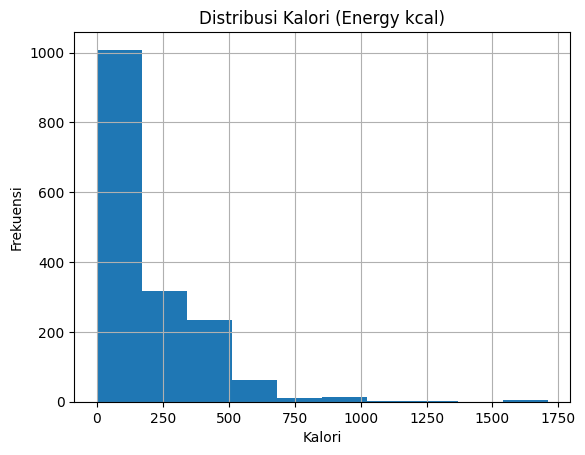

In [ ]:
#Distribusi kalori

plt.figure()
df_main['calories'].hist()
plt.title('Distribusi Kalori (Energy kcal)')
plt.xlabel('Kalori')
plt.ylabel('Frekuensi')
plt.show()

In [ ]:
#Makanan rendah vs tinggi kalori

low_cal = df_main[df_main['calories'] < 100]
high_cal = df_main[df_main['calories'] > 300]

print("Makanan rendah kalori:", low_cal['name'].head())
print("Makanan tinggi kalori:", high_cal['name'].head())

Makanan rendah kalori: 1     Soto pekalongan, masakan
2                    Marie duo
3             Kaparende, sayur
9                    Cumi-cumi
10               Kunyit, segar
Name: name, dtype: object
Makanan tinggi kalori: 4                                   Kacang lebui / iris
5     The coffe bean & tea leaf pure vanilla ice ble...
6                              Dairy queen banana split
11    The coffe bean & tea leaf black forest ice ble...
21           Outback steackhouse slow roasted prime rib
Name: name, dtype: object


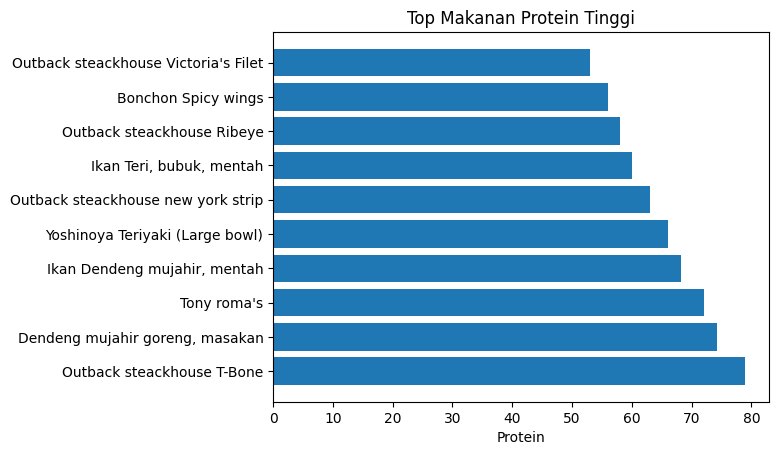

In [ ]:
#Top protein untuk bulking

top_protein = df_main.sort_values(by='proteins', ascending=False).head(10)

plt.figure()
plt.barh(top_protein['name'], top_protein['proteins'])
plt.title('Top Makanan Protein Tinggi')
plt.xlabel('Protein')
plt.show()

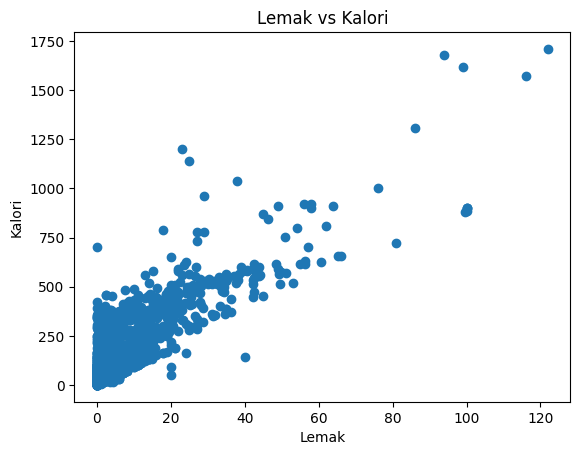

In [ ]:
#Hubungan kalori vs lemak

plt.figure()
plt.scatter(df_main['fat'], df_main['calories'])
plt.title('Lemak vs Kalori')
plt.xlabel('Lemak')
plt.ylabel('Kalori')
plt.show()

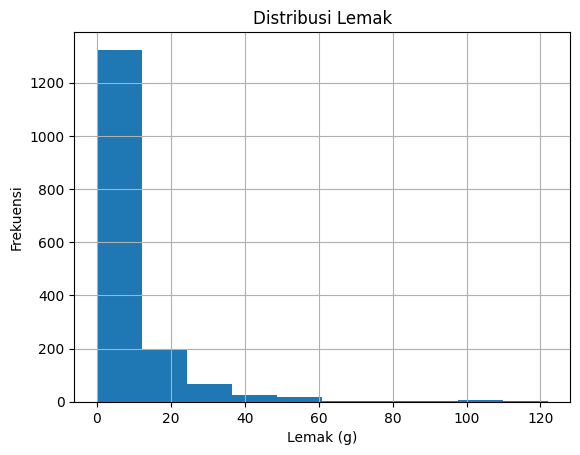

In [ ]:
#Distribusi lemak

plt.figure()
df_main['fat'].hist()
plt.title('Distribusi Lemak')
plt.xlabel('Lemak (g)')
plt.ylabel('Frekuensi')
plt.show()

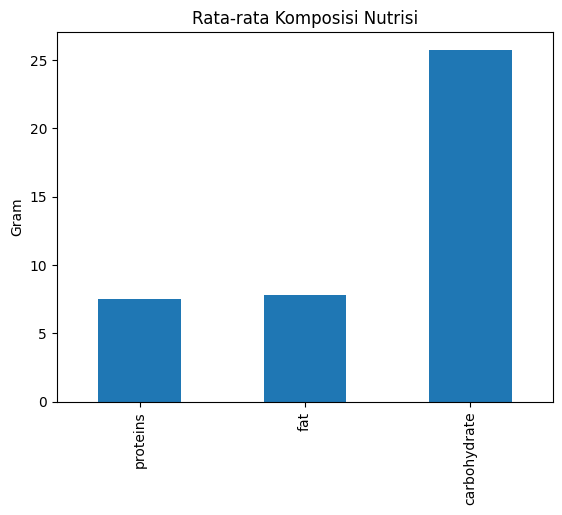

In [ ]:
#Komposisi nutrisi (karbo, protein, lemak)

nutrisi = df_main[['proteins','fat','carbohydrate']].mean()

plt.figure()
nutrisi.plot(kind='bar')
plt.title('Rata-rata Komposisi Nutrisi')
plt.ylabel('Gram')
plt.show()

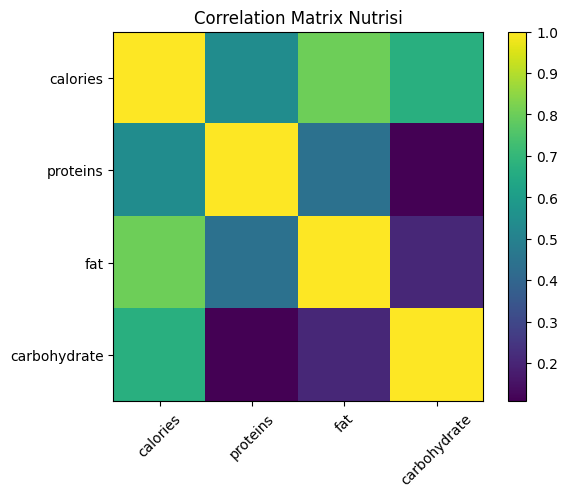

In [ ]:
#Korelasi antar nutrisi

corr = df_main[['calories','proteins','fat','carbohydrate']].corr()

plt.figure()
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title('Correlation Matrix Nutrisi')
plt.show()

**EDA DATASET 2 : BMI**

Visualisasi

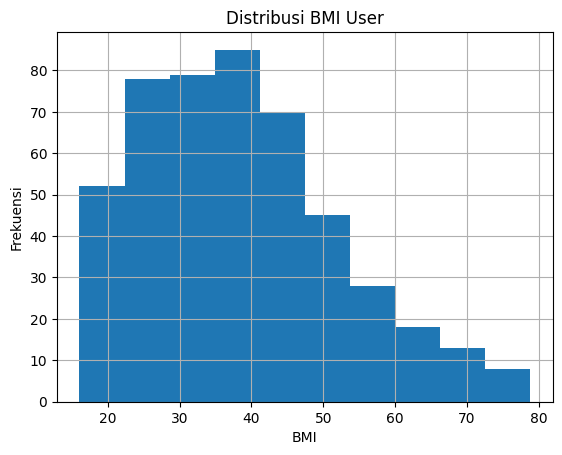

In [ ]:
#Distribusi BMI

# Hitung BMI
df_bmi['BMI'] = df_bmi['weight'] / ((df_bmi['height']/100)**2)

plt.figure()
df_bmi['BMI'].hist()
plt.title('Distribusi BMI User')
plt.xlabel('BMI')
plt.ylabel('Frekuensi')
plt.show()

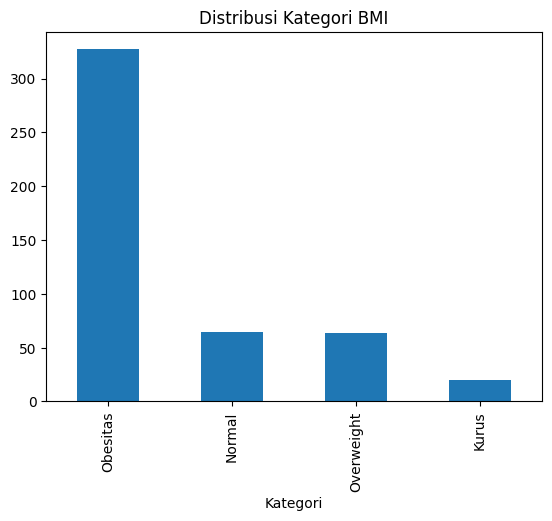

In [ ]:
#kategori BMI

def kategori_bmi(bmi):
    if bmi < 18.5:
        return 'Kurus'
    elif bmi < 25:
        return 'Normal'
    elif bmi < 30:
        return 'Overweight'
    else:
        return 'Obesitas'

df_bmi['Kategori'] = df_bmi['BMI'].apply(kategori_bmi)

df_bmi['Kategori'].value_counts().plot(kind='bar')
plt.title('Distribusi Kategori BMI')
plt.show()

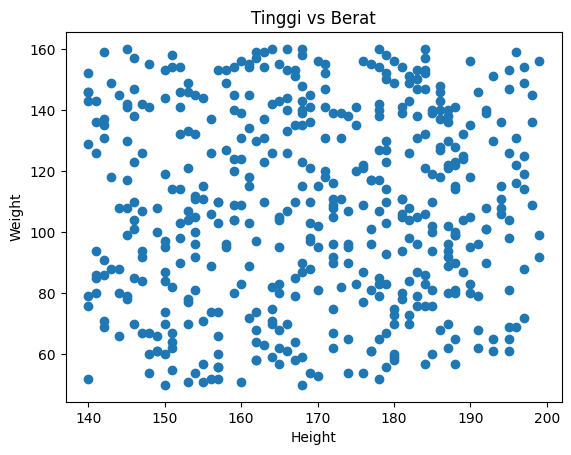

In [ ]:
#height vs weight

plt.figure()
plt.scatter(df_bmi['height'], df_bmi['weight'])
plt.title('Tinggi vs Berat')
plt.xlabel('Height')
plt.ylabel('Weight')
plt.show()

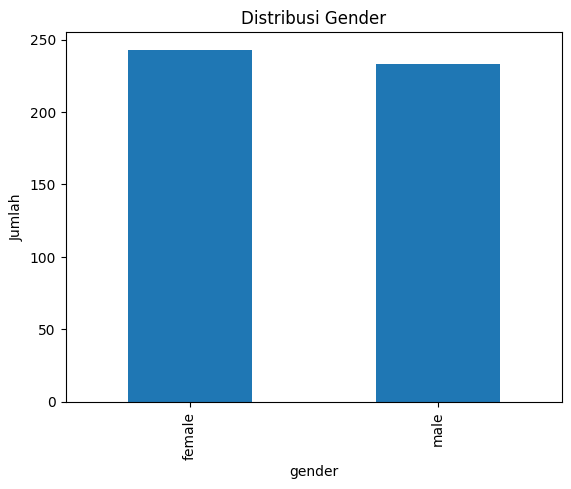

In [ ]:
#Distribusi gender

plt.figure()
df_bmi['gender'].value_counts().plot(kind='bar')
plt.title('Distribusi Gender')
plt.xlabel('gender')
plt.ylabel('Jumlah')
plt.show()

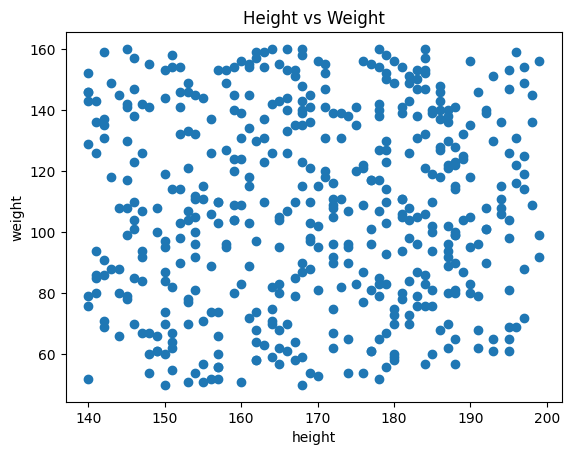

In [ ]:
#Scatter plot tinggi vs berat

plt.figure()
plt.scatter(df_bmi['height'], df_bmi['weight'])
plt.title('Height vs Weight')
plt.xlabel('height')
plt.ylabel('weight')
plt.show()

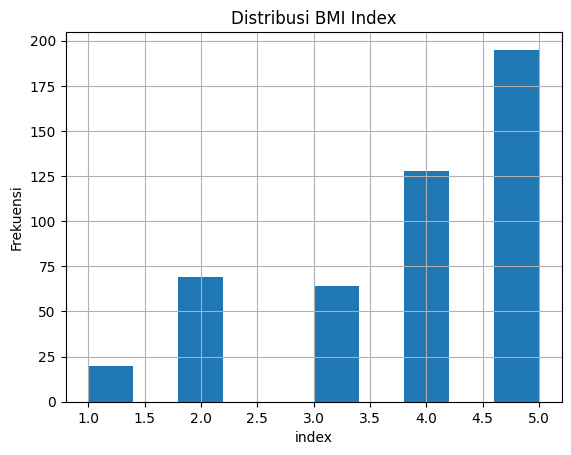

In [ ]:
#Distribusi BMI Index

plt.figure()
df_bmi['index'].hist()
plt.title('Distribusi BMI Index')
plt.xlabel('index')
plt.ylabel('Frekuensi')
plt.show()

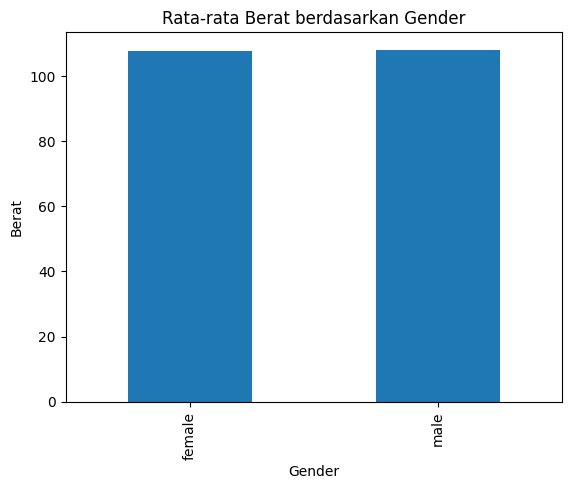

In [ ]:
#rata rata berat berdasarkan gender

avg_weight = df_bmi.groupby('gender')['weight'].mean()

plt.figure()
avg_weight.plot(kind='bar')
plt.title('Rata-rata Berat berdasarkan Gender')
plt.xlabel('Gender')
plt.ylabel('Berat')
plt.show()

In [ ]:
def food_category(row):

  if row['proteins'] >= 15:
    return 'High protein'

  elif row['carbohydrate'] <= 10:
    return 'Low Carb'

  elif row['sugar_g'] <= 5:
    return 'Low Sugar'

  elif row['calories'] <= 150 and row['fat'] <= 10:
    return 'Healthy'

  else:
    return 'Snack'

df_main['food_category'] = df_main.apply(
    food_category,
    axis=1
)



In [ ]:
print(df_main['food_category'].value_counts())

food_category
Low Sugar       704
Low Carb        407
High protein    273
Healthy         165
Snack           102
Name: count, dtype: int64


In [ ]:
df_main[['name', 'food_category']].head()

,name,food_category
0,"Ikan sunu, asin, mentah",High protein
1,"Soto pekalongan, masakan",Low Carb
2,Marie duo,Low Sugar
3,"Kaparende, sayur",Low Carb
4,Kacang lebui / iris,High protein


In [ ]:
# Simpan df main final ke csv
df_main.to_csv('/content/df_main_final.csv',
               index=False)
# simpan df bmi ke csv
df_bmi.to_csv('/content/df_bmi_final.csv',
              index=False)

In [ ]:
files.download('df_main_final.csv')
files.download('df_bmi_final.csv')



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>